### Import libraries and datasets

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import random
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

Normal training dataset

In [ ]:
# Read the CSV file into a DataFrame
path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for i in range(45):
    df = pd.read_csv(all_files[i], encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", all_files[i])
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Filtered, categorized data by labels for more customized training

In [4]:
# Attack data
Brute_Force = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Brute_Force.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Brute_Force.csv')
DDoS = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DDoS.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DDoS.csv')
DoS = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DoS.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DoS.csv')
Spoofing = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Spoofing.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Spoofing.csv')
Recon = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Recon.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Recon.csv')
Web_based = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Web_based.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Web_based.csv')
Mirai = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Mirai.csv', encoding='cp1252', index_col=None, header=0, nrows=230100)
print("Read Completed for ", 'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Mirai.csv')
list_attack = [Brute_Force, DDoS, DoS, Spoofing, Recon, Web_based, Mirai]
attack = pd.concat(list_attack, axis=0, ignore_index=True)
attack = attack.sample(frac=1, random_state=42).reset_index(drop=True)
label_series = pd.Series(attack['Label'])
print(label_series.value_counts())


# Normal data
path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/normal_traffic_cap_live'
all_normal_files = glob.glob(path + "/*.csv")
list_normal = []
for file in all_normal_files:
    normal = pd.read_csv(file, encoding='cp1252', index_col=None, header=0)
    list_normal.append(normal)
    print("Read Completed for ", file)
normal = pd.concat(list_normal, axis=0, ignore_index=True)
normal = normal.drop(columns=['ts'])
normal['Label'] = 0
# normal = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/BENIGN.csv')
# normal = pd.read_csv('c:/Users/ADMIN/Downloads/live_features.csv')

print("Normal: ",normal.shape)
print("Attack: ",attack.shape)

Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Brute_Force.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DDoS.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/DoS.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Spoofing.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Recon.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Web_based.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label_CSV/Mirai.csv
Label
Spoofing       230100
Recon          230100
Mirai          230100
DDoS           230100
DoS            230100
Web_based       23799
Brute_Force     12522
Name: count, dtype: int64
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/normal_traffic_cap_live\live_features_1.csv
Read Completed for  C:/Users/ADMIN/D

### 1st satge model (binary classification)

Ensure column align

In [3]:
common_columns = attack.columns.intersection(normal.columns)
attack = attack[common_columns]
normal = normal[common_columns]

Visual Compare Feature Distributions

In [ ]:
for col in common_columns.drop(['Label']):
    print(col)
    print("Normal: ", len(normal[col]))
    print("Attack: ", len(attack[col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(normal[col], label='Normal traffic', fill=True)
    sns.kdeplot(attack[col], label='Attack traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [25]:
attack = attack.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
print("Attack data: ",attack.shape)
limits = round(attack.shape[0]*90/100)
print(limits)
attack_train = attack[0:limits] 
attack_test = attack[limits:attack.shape[0]]

Attack data:  (1186821, 21)
1068139


In [26]:
normal = normal.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
print("Normal data: ",normal.shape)
limits = round(normal.shape[0]*90/100)
print(limits)
normal_train = normal[0:limits] 
normal_test = normal[limits:normal.shape[0]]

Normal data:  (1186861, 21)
1068175


In [27]:
df = pd.concat([attack_train, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

c:\Users\ADMIN\anaconda3\envs\thinh\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136314 entries, 0 to 2136313
Data columns (total 21 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Header_Length  float64
 1   Protocol Type  int64  
 2   Time_To_Live   float64
 3   Rate           float64
 4   ack_count      float64
 5   HTTP           float64
 6   HTTPS          float64
 7   DNS            float64
 8   TCP            float64
 9   UDP            float64
 10  DHCP           float64
 11  ICMP           float64
 12  IPv            float64
 13  Tot sum        float64
 14  Min            float64
 15  Max            float64
 16  AVG            float64
 17  Std            float64
 18  Tot size       float64
 19  Variance       float64
 20  Label          object 
dtypes: float64(19), int64(1), object(1)
memory usage: 342.3+ MB


In [11]:
df

,Header_Length,Protocol Type,Time_To_Live,Rate,ack_count,HTTP,HTTPS,DNS,TCP,UDP,...,ICMP,IPv,Tot sum,Min,Max,AVG,Std,Tot size,Variance,Label
0,22.40,6,110.40,585.445054,4.0,0.0,0.0,0.0,1.0,0.00,...,0.00,1.00,600.0,60.0,60.0,60.00,0.000000,60.00,0.000000,Recon
1,0.00,0,0.00,1886.012860,0.0,0.0,0.0,0.0,0.0,0.00,...,0.00,0.00,8080.0,110.0,1506.0,808.00,735.756602,8080.00,541337.777778,0
2,20.40,6,101.80,48.631980,5.0,0.0,0.3,0.0,0.5,0.40,...,0.10,1.00,1851.0,66.0,349.0,185.10,118.178255,185.10,13966.100000,Spoofing
3,20.00,6,60.00,51.353710,3.0,0.1,0.5,0.0,0.6,0.30,...,0.10,1.00,687.0,60.0,103.0,68.70,13.679262,68.70,187.122222,Recon
4,20.00,6,64.00,3166.157632,28.0,1.0,0.0,0.0,1.0,0.00,...,0.00,1.00,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000000,DoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2136309,40.00,6,76.20,848.019410,10.0,0.0,1.0,0.0,1.0,0.00,...,0.00,1.00,10704.0,54.0,1506.0,1070.40,701.382635,10704.00,491937.600000,0
2136310,0.00,0,0.00,1432.383034,0.0,0.0,0.0,0.0,0.0,0.00,...,0.00,0.00,11743.0,97.0,1294.0,1174.30,378.524636,11743.00,143280.900000,0
2136311,7.92,17,63.36,3232.056222,0.0,0.0,0.0,0.0,0.0,0.99,...,0.00,0.99,54906.0,60.0,554.0,549.06,49.400000,549.06,2440.360000,Mirai
2136312,7.68,17,71.64,18660.426213,0.0,0.0,0.0,0.0,0.0,0.96,...,0.04,1.00,6040.0,60.0,70.0,60.40,1.969464,60.40,3.878788,DDoS


Grouping main categories into one category for binary classification

In [28]:
# Grouping
Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']

def classify_attacks(data):
    data['Label'].replace(Attack,1,inplace=True)
classify_attacks(df)

In [29]:
df['Label'].value_counts()

Label
0    1068175
1    1068139
Name: count, dtype: int64

These are the under performance sub-categories according to the Feature importance of Random Forest model

In [ ]:
delete_cat = ['DDOS-RSTFINFLOOD', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'RECON-OSSCAN', 'RECON-PORTSCAN']

df = df[~df['Label'].isin(delete_cat)].reset_index(drop=True)

Grouping sub-categories into one category for binary classification

In [ ]:
# Grouping
Attack = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',     
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',         
        'DDOS-ICMP_FRAGMENTATION',
        'DDOS-RSTFINFLOOD', 
        'DDOS-SYNONYMOUSIP_FLOOD', 
        'DDOS-SYN_FLOOD', 
        'DDOS-TCP_FLOOD',
        'DOS-UDP_FLOOD',       
        'DOS-HTTP_FLOOD',
        'DOS-SYN_FLOOD', 
        'DOS-TCP_FLOOD',
        'MITM-ARPSPOOFING',     
        'DNS_SPOOFING',
        'DICTIONARYBRUTEFORCE',
        'RECON-HOSTDISCOVERY',                
        'RECON-PINGSWEEP',
        'RECON-OSSCAN', 
        'RECON-PORTSCAN'       
        'VULNERABILITYSCAN',
        'SQLINJECTION',        
        'BROWSERHIJACKING',         
        'COMMANDINJECTION',       
        'XSS',         
        'BACKDOOR_MALWARE',          
        'UPLOADING_ATTACK',
        'MIRAI-GREETH_FLOOD',     
        'MIRAI-UDPPLAIN',     
        'MIRAI-GREIP_FLOOD']

def classify_attacks(data):
    data['Label'].replace(Attack,'Attack',inplace=True)
classify_attacks(df)

Grouping sub-category into main categories for multiclass classification

In [ ]:
# Grouping
# DDoS = ['DDOS-ACK_FRAGMENTATION',     
#         'DDOS-UDP_FLOOD',       
#         'DDOS-SLOWLORIS',               
#         'DDOS-ICMP_FLOOD',        
#         'DDOS-RSTFINFLOOD',    
#         'DDOS-PSHACK_FLOOD',        
#         'DDOS-HTTP_FLOOD',              
#         'DDOS-UDP_FRAGMENTATION',     
#         'DDOS-TCP_FLOOD',  
#         'DDOS-SYN_FLOOD',        
#         'DDOS-SYNONYMOUSIP_FLOOD',    
#         'DDOS-ICMP_FRAGMENTATION']

# DoS = ['DOS-UDP_FLOOD',    
#        'DOS-TCP_FLOOD',    
#        'DOS-SYN_FLOOD',    
#        'DOS-HTTP_FLOOD']

# Spoofing = ['MITM-ARPSPOOFING',     
#             'DNS_SPOOFING']

# Brute_force = ['DICTIONARYBRUTEFORCE']

# Recon = ['RECON-HOSTDISCOVERY', 
#          'RECON-OSSCAN',     
#          'RECON-PORTSCAN',               
#          'RECON-PINGSWEEP',         
#          'VULNERABILITYSCAN']

# Web_based = ['SQLINJECTION',        
#              'BROWSERHIJACKING',         
#              'COMMANDINJECTION',       
#              'XSS',         
#              'BACKDOOR_MALWARE',          
#              'UPLOADING_ATTACK']

# Mirai = ['MIRAI-GREETH_FLOOD',     
#          'MIRAI-UDPPLAIN',     
#          'MIRAI-GREIP_FLOOD']



# def classify_attacks(data):
#     data['Label'].replace(DDoS,'DDoS',inplace=True)
#     data['Label'].replace(DoS,'DoS',inplace=True)
#     data['Label'].replace(Spoofing,'Spoofing',inplace=True)
#     data['Label'].replace(Brute_force,'Brute_Force',inplace=True)
#     data['Label'].replace(Recon,'Recon',inplace=True)
#     data['Label'].replace(Web_based,'Web_based',inplace=True)
#     data['Label'].replace(Mirai,'Mirai',inplace=True)
# classify_attacks(df)

Export csv that contain only 1 label

In [ ]:
# category_counts = df["Label"].value_counts()
# category_names = category_counts.index.tolist()

# for cat in category_names:
#     csv_by_label = df[df['Label'] == cat]
#     csv_by_label.to_csv('Label CSV/{}.csv'.format(cat), index=False)

In [30]:
# Train set preprocessing
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

In [31]:
columns_name = df.drop(columns=['Label']).columns

In [8]:
X_train_val = df

In [32]:
# Create test data
X_train_val = df.drop(columns=['Label'])
Y_train_val = df['Label']

In [28]:
print(X_train_val.shape)
print(Y_train_val.shape)

(1506446, 20)
(1506446,)


In [10]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
1    828646
0    677800
Name: count, dtype: int64


In [33]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [ ]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

In [12]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    677800
1    677800
Name: count, dtype: int64


In [34]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)
#X_test_scaled = scaler.fit_transform(X_test)

In [35]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [37]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=20, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [38]:
y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    135388
           1       1.00      1.00      1.00    135732

    accuracy                           1.00    271120
   macro avg       1.00      1.00      1.00    271120
weighted avg       1.00      1.00      1.00    271120



In [39]:
# Save the model
with open('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Models/CIC_models/frst_model_1st_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [15]:
# Load the model
with open('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Models/CIC_models/frst_model_1st_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [39]:
# Test set preprocessing
normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

for i in range(200):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24648\502124503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_test.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24648\502124503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24648\502124503.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org

Sample 0: Predicted = 0, Actual = 0
Sample 1: Predicted = 0, Actual = 0
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 0, Actual = 0
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 0, Actual = 0
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 0, Actual = 0
Sample 9: Predicted = 0, Actual = 0
Sample 10: Predicted = 0, Actual = 0
Sample 11: Predicted = 0, Actual = 0
Sample 12: Predicted = 0, Actual = 0
Sample 13: Predicted = 0, Actual = 0
Sample 14: Predicted = 0, Actual = 0
Sample 15: Predicted = 0, Actual = 0
Sample 16: Predicted = 0, Actual = 0
Sample 17: Predicted = 0, Actual = 0
Sample 18: Predicted = 0, Actual = 0
Sample 19: Predicted = 0, Actual = 0
Sample 20: Predicted = 0, Actual = 0
Sample 21: Predicted = 0, Actual = 0
Sample 22: Predicted = 0, Actual = 0
Sample 23: Predicted = 0, Actual = 0
Sample 24: Predicted = 0, Actual = 0
Sample 25: Predicted = 0, Actual = 0
Sample 26: Predicted = 0, Actual = 0
Sample 27: 

In [46]:
attack_sample = Recon.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])

# Test set preprocessing
attack_sample.drop_duplicates(keep='first', inplace = True)
attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_sample.reset_index(drop=True, inplace=True)

X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

for i in range(200):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

Sample 0: Predicted = 0, Actual = Recon
Sample 1: Predicted = 0, Actual = Recon
Sample 2: Predicted = 1, Actual = Recon
Sample 3: Predicted = 0, Actual = Recon
Sample 4: Predicted = 0, Actual = Recon
Sample 5: Predicted = 0, Actual = Recon
Sample 6: Predicted = 1, Actual = Recon
Sample 7: Predicted = 0, Actual = Recon
Sample 8: Predicted = 1, Actual = Recon
Sample 9: Predicted = 1, Actual = Recon
Sample 10: Predicted = 0, Actual = Recon
Sample 11: Predicted = 0, Actual = Recon
Sample 12: Predicted = 0, Actual = Recon
Sample 13: Predicted = 0, Actual = Recon
Sample 14: Predicted = 0, Actual = Recon
Sample 15: Predicted = 0, Actual = Recon
Sample 16: Predicted = 0, Actual = Recon
Sample 17: Predicted = 0, Actual = Recon
Sample 18: Predicted = 0, Actual = Recon
Sample 19: Predicted = 0, Actual = Recon
Sample 20: Predicted = 0, Actual = Recon
Sample 21: Predicted = 0, Actual = Recon
Sample 22: Predicted = 0, Actual = Recon
Sample 23: Predicted = 1, Actual = Recon
Sample 24: Predicted = 0, 

### 2nd stage model (multiclass classification)

In [8]:
X_dist_test = attack.drop(columns=['Label'])
Y_dist_test = attack['Label']

In [ ]:
for col in X_dist_test:
    print(col)
    print("Spoofing: ", len(Spoofing[:12522][col]))
    print("Recon: ", len(Recon[:12522][col]))
    print("Mirai: ", len(Mirai[:12522][col]))
    print("DDoS: ", len(DDoS[:12522][col]))
    print("DoS: ", len(DoS[:12522][col]))
    print("Web_based: ", len(Web_based[:12522][col]))
    print("Brute_Force: ", len(Brute_Force[:12522][col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
    sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
    sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
    sns.kdeplot(DDoS[:12522][col], label='DDoS traffic', fill=True)
    sns.kdeplot(DoS[:12522][col], label='DoS traffic', fill=True)
    sns.kdeplot(Web_based[:12522][col], label='Web_based traffic', fill=True)
    sns.kdeplot(Brute_Force[:12522][col], label='Brute_Force traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [13]:
attack = attack.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'DHCP', 'ARP', 'IGMP', 'IPv', 'LLC', 'Min', 'IAT', 'Number', 'Variance'])
print("Attack data: ",attack.shape)
limits = round(attack.shape[0]*90/100)
print(limits)
attack_train = attack[0:limits] 
attack_test = attack[limits:attack.shape[0]]

Attack data:  (1186821, 17)
1068139


In [14]:
attack_train

,Header_Length,Protocol Type,Time_To_Live,Rate,ack_flag_number,ack_count,HTTP,HTTPS,TCP,UDP,ICMP,Tot sum,Max,AVG,Std,Tot size,Label
0,29.60,6,78.90,502.209610,0.7,7.0,0.2,0.7,0.9,0.10,0.00,7520.0,1500.0,752.00,704.630400,752.00,Spoofing
1,21.20,6,173.10,933.706730,0.6,6.0,0.1,0.0,0.9,0.10,0.00,776.0,230.0,77.60,53.581091,77.60,Recon
2,36.80,6,173.80,1854.245800,1.0,10.0,0.0,1.0,1.0,0.00,0.00,9300.0,1500.0,930.00,733.288483,930.00,Spoofing
3,0.08,47,64.64,5813.955809,0.0,0.0,0.0,0.0,0.0,0.01,0.00,57317.0,578.0,573.17,48.300000,573.17,Mirai
4,0.00,1,63.36,56306.940529,0.0,0.0,0.0,0.0,0.0,0.00,0.99,6000.0,60.0,60.00,0.000000,60.00,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068134,12.00,17,57.20,81.578073,0.2,2.0,0.0,0.2,0.2,0.70,0.00,702.0,156.0,70.20,30.205960,70.20,Recon
1068135,22.00,6,89.10,51.059449,0.8,8.0,0.0,0.4,0.8,0.00,0.00,938.0,156.0,93.80,35.291799,93.80,Recon
1068136,20.00,6,64.00,54798.850274,0.0,0.0,0.0,0.0,1.0,0.00,0.00,6000.0,60.0,60.00,0.000000,60.00,DDoS
1068137,43.20,6,99.40,14857.612469,1.0,10.0,1.0,0.0,1.0,0.00,0.00,11940.0,2858.0,1194.00,1088.581544,1194.00,Recon


In [15]:
# Train set preprocessing
attack_train.drop_duplicates(keep='first', inplace = True)
attack_train.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_train.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_train.reset_index(drop=True, inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30276\2124910360.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attack_train.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30276\2124910360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attack_train.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30276\2124910360.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydat

In [16]:
# Create test data
X_train_val = attack_train.drop(columns=['Label'])
Y_train_val = attack_train['Label']

In [17]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
Recon          203910
Spoofing       189407
Mirai          180586
DoS            130821
DDoS           112874
Web_based       21113
Brute_Force     11287
Name: count, dtype: int64


In [ ]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [18]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

(1427370,)
(1427370, 16)


In [19]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
Spoofing       203910
Recon          203910
Mirai          203910
DDoS           203910
DoS            203910
Brute_Force    203910
Web_based      203910
Name: count, dtype: int64


In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)

In [21]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [24]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=15,   # Reduce splits on small nodes
                                    min_samples_leaf=15,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=15, min_samples_split=15,
                       n_jobs=-1, random_state=42)

In [25]:
y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

 Brute_Force       0.84      0.85      0.85     40912
        DDoS       0.84      0.64      0.73     40882
         DoS       0.71      0.87      0.78     40786
       Mirai       1.00      1.00      1.00     40838
       Recon       0.75      0.91      0.82     40651
    Spoofing       0.90      0.77      0.83     40570
   Web_based       0.85      0.78      0.81     40835

    accuracy                           0.83    285474
   macro avg       0.84      0.83      0.83    285474
weighted avg       0.84      0.83      0.83    285474



### Model train on Normal traffic only (Unsupervised learning)

Unsupervised learning for Anomaly Detection using One-Class Classification (or Novelty Detection)

In [ ]:
model = IsolationForest(n_estimators=1000,       # Number of trees in the forest
                            max_samples='auto',        # Number of samples to draw for each tree (sub-sampling)
                            contamination='auto',   
                            random_state=42,
                            n_jobs=-1)              # Use all CPU cores
model.fit(X_train_scaled)

IsolationForest(n_estimators=1000, n_jobs=-1, random_state=42)

Unsupervised learning for Anomaly Detection using Autoencoder

In [10]:
import keras
from keras.models import Sequential
from keras import Input, optimizers, layers
from keras.layers import *

In [11]:
_features = X_train_scaled.shape[1]
print(_features)

20


In [12]:
model = Sequential([
    Input(shape=(_features,)),
    
    # Autoencoder
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),   # bottleneck
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),

    # Classification layer
    Dense(_features, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │        10,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,420 (1.40 MB)

 Trainable params: 366,420 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
opt = optimizers.Adam(learning_rate=0.0001)
# model.compile(loss='mse', optimizer=opt, metrics=[keras.metrics.F1Score(average=None, threshold=None, name="f1_score", dtype=None)])
model.compile(loss='mse', optimizer=opt)
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [15]:
start_fit = time.time()
history = model.fit(X_train_scaled, X_train_scaled,
                    batch_size=256,
                    epochs=50,
                    verbose=True,
                    validation_split= 0.1)    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time)) 

Epoch 1/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0343 - val_loss: 1.7774e-04
Epoch 2/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 1.3298e-04 - val_loss: 8.4486e-05
Epoch 3/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 6.7505e-05 - val_loss: 5.4332e-05
Epoch 4/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.8017e-05 - val_loss: 3.2113e-05
Epoch 5/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.5796e-05 - val_loss: 2.3190e-05
Epoch 6/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.1333e-05 - val_loss: 2.1382e-05
Epoch 7/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.9156e-05 - val_loss: 1.7845e-05
Epoch 8/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.7413e-05 - val_loss: 1.6498e-05
Epoch 9/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.4226e-05 - val_loss: 1.6066e-05
Epoch 10/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.4125e-05 - val_loss: 1.4782e-05
Epoch 11/50
2383/2383 ━━━━━━━━━━━

In [20]:
#Let's try to get latent learnt representation by autoencoder
hidden_representation = Sequential()
hidden_representation.add(model.layers[0])
hidden_representation.add(model.layers[1])
hidden_representation.add(model.layers[2])
hidden_representation.add(model.layers[3])

In [ ]:
hidden_representation.summary()

In [26]:
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

# attack_test = attack_test.drop(columns=['Tot size', 'Protocol Type'])
# attack_test = attack_test.drop(columns=['Label'])

# # Grouping
# Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']
# def classify_attacks(data):
#     data['Label'].replace(Attack,1,inplace=True)
# classify_attacks(attack_test)

normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

# normal_test = normal_test.drop(columns=['Tot size', 'Protocol Type'])
# normal_test = normal_test.drop(columns=['Label'])

norm_hid_rep = hidden_representation.predict(normal_test)
fraud_hid_rep = hidden_representation.predict(attack_test)

3648/3648 ━━━━━━━━━━━━━━━━━━━━ 2s 504us/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 2s 479us/step


In [30]:
from sklearn.manifold import TSNE

def tsne_plot(x1, y1, name="graph.png"):
    
    #Scale features to improve the training ability of TSNE.
    standard_scaler = StandardScaler()
    df2_std = standard_scaler.fit_transform(x1)

    tsne = TSNE(n_components=2, random_state=0)
    x_test_2d = tsne.fit_transform(df2_std)
    
    #Build the scatter plot with the two types of transactions.
    color_map = {0:'green', 1:'red'}
    plt.figure()
    for idx, cl in enumerate(np.unique(y1)):
        plt.scatter(x = x_test_2d[y1==cl,0], 
                    y = x_test_2d[y1==cl,1], 
                    c = color_map[idx], 
                    label = cl)
    plt.xlabel('X in t-SNE')
    plt.ylabel('Y in t-SNE')
    plt.legend(loc='upper left')
    plt.title('t-SNE visualization of test data')
    plt.show()

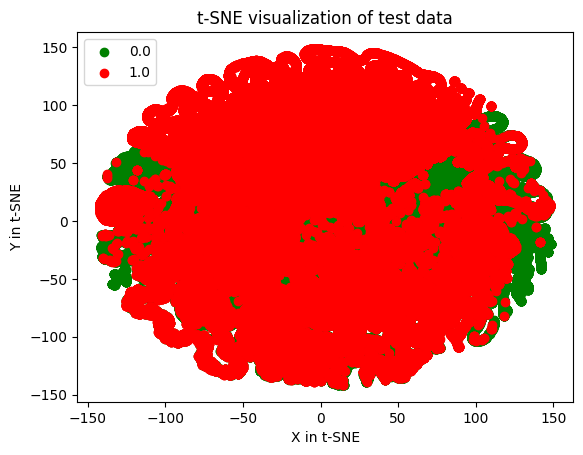

In [31]:
#Let's try to visualize TSNE again for the learnt representation
rep_x = np.append(norm_hid_rep, fraud_hid_rep, axis = 0)
y_n = np.zeros(norm_hid_rep.shape[0])
y_f = np.ones(fraud_hid_rep.shape[0])
rep_y = np.append(y_n, y_f)

tsne_plot(rep_x, rep_y)

In [36]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
clf = LogisticRegression(solver="lbfgs").fit(train_x, train_y)
pred_y = clf.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.77      0.96      0.86     29207
         1.0       0.94      0.67      0.79     25123

    accuracy                           0.83     54330
   macro avg       0.86      0.82      0.82     54330
weighted avg       0.85      0.83      0.82     54330


Accuracy Score:  0.8296889379716547


c:\Users\ADMIN\anaconda3\envs\thinh\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(train_x, train_y)
pred_y = frst_model.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93     29157
         1.0       0.96      0.88      0.92     25173

    accuracy                           0.93     54330
   macro avg       0.93      0.92      0.93     54330
weighted avg       0.93      0.93      0.93     54330


Accuracy Score:  0.9262470090189582


In [20]:
# sample_set = attack_test
sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

X_sample = sample_set.drop(columns=['Label'])
# X_sample = sample_set.drop(columns=['Label', 'Tot size', 'Protocol Type'])
# Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# Step 1: Get reconstruction errors on validation normal traffic
val_reconstructions = model.predict(X_sample_scaled)
val_mse = np.mean(np.power(X_sample_scaled - val_reconstructions, 2), axis=1)

# Step 2: Compute threshold (e.g., 95th percentile)
threshold = np.percentile(val_mse, 50)
print(f"Anomaly Detection Threshold (95th percentile): {threshold:.6f}")

# Step 3: Loop through test samples to classify
for i in range(100):
    # Get i-th test sample (already scaled)
    sample = X_sample_scaled[i].reshape(1, -1)

    # Predict reconstruction
    reconstruction = model.predict(sample)

    # Calculate reconstruction error (MSE)
    mse = np.mean(np.power(sample - reconstruction, 2))

    # Decision based on threshold
    label = "Anomaly Detected!" if mse > threshold else "Normal Traffic."
    
    print(f"Sample {i}: MSE = {mse:.6f} --> {label}")


 138/3593 ━━━━━━━━━━━━━━━━━━━━ 2s 740us/step

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1377631023.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_set.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1377631023.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1377631023.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.or

3593/3593 ━━━━━━━━━━━━━━━━━━━━ 2s 680us/step
Anomaly Detection Threshold (95th percentile): 0.000223
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 0: MSE = 0.000169 --> Normal Traffic.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 1: MSE = 0.000150 --> Normal Traffic.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 2: MSE = 0.000339 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 3: MSE = 0.013091 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 4: MSE = 0.012728 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 5: MSE = 0.013052 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 6: MSE = 0.002127 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Sample 7: MSE = 0.000244 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Sample 8: MSE = 0.001309 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 9: MSE = 0.002090 --> Anomaly Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample 10: MSE 

In [17]:
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/BENIGN.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Mirai.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Brute_Force.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/DDoS.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/DoS.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Recon.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Spoofing.csv')
# test_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Web_based.csv')
test_set = normal_train

# Test set preprocessing
test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)
test_set = test_set

X_normal_sample = test_set.drop(columns=['Tot size', 'Protocol Type'])
# X_normal_sample = test_set.drop(columns=['Label'])
# Y_normal_sample = test_set['Label']

X_normal_sample_scaled = scaler.fit_transform(X_normal_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_normal_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    # actual = Y_normal_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}")
    # print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1476776824.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1476776824.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24376\1476776824.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org

NameError: name 'frst_model' is not defined

In [74]:
# Test set preprocessing
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

X_attack_sample = attack_test.drop(columns=['Label'])
Y_attack_sample = attack_test['Label']

X_attack_sample_scaled = scaler.fit_transform(X_attack_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_attack_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]
    actual = Y_attack_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample 0: Predicted = [1. 1.], Actual = DoS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10244\1361943758.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attack_test.drop_duplicates(keep='first', inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10244\1361943758.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10244\1361943758.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Sample 1: Predicted = [1. 1.], Actual = Web_based
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Sample 2: Predicted = [0.99817204 0.9982363 ], Actual = Spoofing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample 3: Predicted = [0.71770227 0.71950525], Actual = Spoofing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Sample 4: Predicted = [0.99999994 0.99999994], Actual = Spoofing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Sample 5: Predicted = [1. 1.], Actual = Brute_Force
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Sample 6: Predicted = [0.99999994 0.99999994], Actual = Recon
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 7: Predicted = [1. 1.], Actual = DoS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 8: Predicted = [1. 1.], Actual = Spoofing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample 9: Predicted = [1. 1.], Actual = Mirai
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample 10: Predicted = [1. 1.], Actual = DoS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample 11: Predicted = [1. 1.], Actual 

If val loss increases while train loss keeps decreasing, it’s overfitting

In [ ]:
# Assuming 'history' is the result from model.fit()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [ ]:
sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/BENIGN.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Mirai.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Brute_Force.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/DDoS.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/DoS.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Recon.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Spoofing.csv')
# sample_set = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Label CSV/Web_based.csv')
# sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

# X_sample = sample_set
X_sample = sample_set.drop(columns=['Label'])
Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# # Predict Anomaly (-1 = Anomaly, 1 = Normal)
# predictions = model.predict(X_sample_scaled)

# # Optional: Get anomaly scores (the lower, the more anomalous)
# anomaly_scores = model.decision_function(X_sample_scaled)

# print(predictions)
# print(anomaly_scores)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

Sample 0: Predicted = 1
Sample 1: Predicted = 1
Sample 2: Predicted = -1
Sample 3: Predicted = 1
Sample 4: Predicted = -1
Sample 5: Predicted = -1
Sample 6: Predicted = 1
Sample 7: Predicted = -1
Sample 8: Predicted = -1
Sample 9: Predicted = -1
Sample 10: Predicted = -1
Sample 11: Predicted = -1
Sample 12: Predicted = -1
Sample 13: Predicted = -1
Sample 14: Predicted = 1
Sample 15: Predicted = -1
Sample 16: Predicted = 1
Sample 17: Predicted = -1
Sample 18: Predicted = -1
Sample 19: Predicted = 1
Sample 20: Predicted = -1
Sample 21: Predicted = -1
Sample 22: Predicted = -1
Sample 23: Predicted = -1
Sample 24: Predicted = 1
Sample 25: Predicted = -1
Sample 26: Predicted = -1
Sample 27: Predicted = -1
Sample 28: Predicted = -1
Sample 29: Predicted = 1
Sample 30: Predicted = -1
Sample 31: Predicted = 1
Sample 32: Predicted = 1
Sample 33: Predicted = 1
Sample 34: Predicted = -1
Sample 35: Predicted = -1
Sample 36: Predicted = 1
Sample 37: Predicted = -1
Sample 38: Predicted = 1
Sample 39:

In [ ]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top Feature Importances in Random Forest")
plt.show()

In [2]:
my_benign = pd.read_csv('C:/Users/ADMIN/Downloads/live_features.csv')
my_benign = my_benign.drop(columns=['ts'])
# # print(my_benign.info())
# my_benign = my_benign.drop(columns=['ts', 'fin_count', 'fin_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_number', 'Number'])
# # Test set preprocessing
# my_benign.drop_duplicates(keep='first', inplace = True)
# my_benign.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
# my_benign.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
# my_benign.reset_index(drop=True, inplace=True)
# my_benign = scaler.fit_transform(my_benign)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/ADMIN/Downloads/live_features.csv'

In [ ]:
for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = my_benign[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
data_combined = pd.concat([cic_benign, my_benign])
data_scaled = scaler.fit_transform(data_combined)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

labels = np.array(['CIC'] * len(cic_benign) + ['Mine'] * len(my_benign))

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels)
plt.title('PCA of Benign Data')
plt.show()